# When Models Don't Know What They Don't Know
## Domain Shift and Uncertainty Estimation in Medical Image Classification

---

### Motivation

A deep learning model that performs well in the lab can fail silently in the clinic.  
The problem is not just that the model makes mistakes — it is that it makes mistakes **confidently**.

This is the domain shift problem: a model trained on data from one distribution (one hospital, one scanner, one staining protocol) is deployed on data from a different distribution, and no one notices until harm is done.

In this notebook we demonstrate four things:

1. **How domain shift silently degrades performance** — a model trained on colorectal cancer histology patches (PathMNIST) is evaluated on kidney tissue microscopy images (TissueMNIST). Both are tissue images. The model has never been told it is out of distribution.
2. **How a naive model gives high-confidence wrong predictions** — standard softmax confidence scores are not reliable uncertainty estimates.
3. **How Monte Carlo Dropout provides meaningful uncertainty estimates** — high variance across stochastic forward passes signals that the model genuinely does not know.
4. **How Grad-CAM reveals what the model attends to** — making the failure mode interpretable.

---

### Datasets

- **PathMNIST** (source domain): H&E stained colorectal cancer histology patches, 9 tissue classes, RGB. From NCT-CRC-HE-100K.
- **TissueMNIST** (target domain): Human kidney cortex microscopy, 8 cell/tissue types, grayscale. From the Human Protein Atlas.

Both contain tissue images at cellular scale. The shift arises from different organs, staining protocols, and imaging modalities — the kind of shift that occurs in real clinical deployment.

## 0. Setup

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cv2

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import transforms, models

import medmnist
from medmnist import PathMNIST, TissueMNIST, INFO

import warnings
warnings.filterwarnings('ignore')

os.makedirs('figures', exist_ok=True)

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
print(f'MedMNIST version: {medmnist.__version__}')

Device: cpu
MedMNIST version: 3.0.2


## 1. Load Data

In [3]:
transform_path = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# TissueMNIST is grayscale; replicate to 3 channels to match model input
transform_tissue = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.repeat(3, 1, 1) if x.shape[0] == 1 else x),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

path_train  = PathMNIST(split='train', transform=transform_path,   download=True)
path_val    = PathMNIST(split='val',   transform=transform_path,   download=True)
path_test   = PathMNIST(split='test',  transform=transform_path,   download=True)
tissue_test = TissueMNIST(split='test', transform=transform_tissue, download=True)

N_TRAIN, N_VAL, N_TEST = 8000, 1000, 1000

path_train_sub  = Subset(path_train,  torch.randperm(len(path_train))[:N_TRAIN])
path_val_sub    = Subset(path_val,    torch.randperm(len(path_val))[:N_VAL])
path_test_sub   = Subset(path_test,   torch.randperm(len(path_test))[:N_TEST])
tissue_test_sub = Subset(tissue_test, torch.randperm(len(tissue_test))[:N_TEST])

train_loader  = DataLoader(path_train_sub,  batch_size=64, shuffle=True,  num_workers=2)
val_loader    = DataLoader(path_val_sub,    batch_size=64, shuffle=False, num_workers=2)
source_loader = DataLoader(path_test_sub,   batch_size=64, shuffle=False, num_workers=2)
target_loader = DataLoader(tissue_test_sub, batch_size=64, shuffle=False, num_workers=2)

N_CLASSES     = len(INFO['pathmnist']['label'])
SOURCE_LABELS = INFO['pathmnist']['label']
TARGET_LABELS = INFO['tissuemnist']['label']

print(f"Source (PathMNIST):   {N_TRAIN} train | {N_VAL} val | {N_TEST} test | {N_CLASSES} classes")
print(f"Target (TissueMNIST): {N_TEST} test | {len(TARGET_LABELS)} classes")

100%|██████████| 206M/206M [01:10<00:00, 2.93MB/s]
100%|██████████| 125M/125M [00:08<00:00, 14.9MB/s]


Source (PathMNIST):   8000 train | 1000 val | 1000 test | 9 classes
Target (TissueMNIST): 1000 test | 8 classes


### 1.1 Visualize the Domain Gap

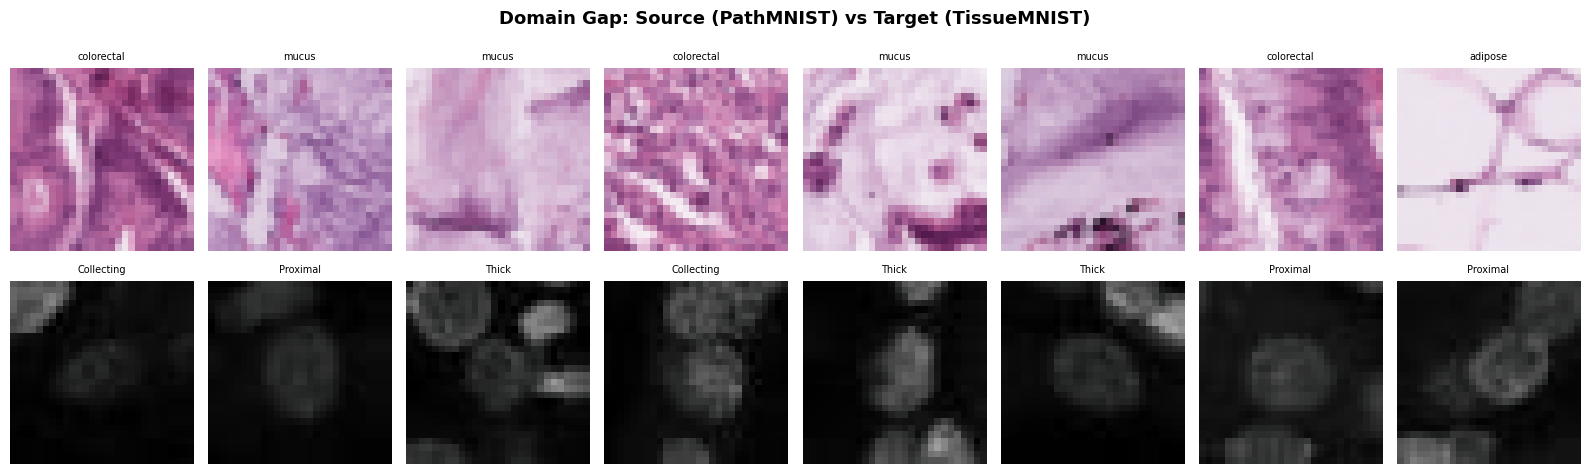

In [4]:
def denormalize(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    return (tensor * std + mean).clamp(0, 1)

fig, axes = plt.subplots(2, 8, figsize=(16, 5))
fig.suptitle('Domain Gap: Source (PathMNIST) vs Target (TissueMNIST)',
             fontsize=13, fontweight='bold')

for i in range(8):
    img, label = path_test[i]
    axes[0, i].imshow(denormalize(img).permute(1,2,0).numpy())
    axes[0, i].set_title(SOURCE_LABELS[str(label.item())].split()[0], fontsize=7)
    axes[0, i].axis('off')
axes[0, 0].set_ylabel('Source\n(PathMNIST)', fontsize=9, rotation=90, labelpad=40)

for i in range(8):
    img, label = tissue_test[i]
    axes[1, i].imshow(denormalize(img).permute(1,2,0).numpy())
    axes[1, i].set_title(TARGET_LABELS[str(label.item())].split()[0], fontsize=7)
    axes[1, i].axis('off')
axes[1, 0].set_ylabel('Target\n(TissueMNIST)', fontsize=9, rotation=90, labelpad=40)

plt.tight_layout()
plt.savefig('figures/domain_gap.png', dpi=150, bbox_inches='tight')
plt.show()